# Phase 3 — Spatial Analysis of Economic and Demographic Data
**Project:** Forecasting the Recovery of Global Economies from Shocks through Time Series Modeling

**Goals:**
1. Global choropleth maps — GDP, recovery speed, recovery quality
2. Regional comparison of GDP trends and shock impact
3. Correlation analysis between economic and demographic indicators
4. Country clustering by recovery profile
5. Top/bottom recovery performers

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

OUTPUT_DIR = r'..\output'
print('Libraries imported successfully')

Libraries imported successfully


## 2. Load Enriched Dataset

In [2]:
df = pd.read_csv(r'..\output\dashboard_dataset.csv')
recovery = pd.read_csv(r'..\output\recovery_summary.csv')

df = df.sort_values(['country_code', 'year']).reset_index(drop=True)

print('Dashboard dataset shape:', df.shape)
print('Recovery summary shape:', recovery.shape)
print('Countries:', df['country_code'].nunique())
print('Years:', df['year'].min(), '-', df['year'].max())
df.head(3)

Dashboard dataset shape: (7240, 25)
Recovery summary shape: (420, 5)
Countries: 212
Years: 1990 - 2024


,country_code,year,gdp_per_capita,population,inflation_hcpi,dependency_ratio,employment_rate,interest_rate,is_shock,shock_label,gdp_growth_rate,recovery_speed_covid_2020,recovery_speed_recession_2008,recovery_quality_covid_2020,recovery_quality_recession_2008,gdp_lag_1,gdp_lag_2,growth_lag_1,gdp_rolling_mean_3yr,pre_shock_baseline_2008,pre_shock_baseline_2020,gdp_dev_from_2008_baseline,gdp_dev_from_2020_baseline,world_gdp_growth,pct_countries_contracting
0,ABW,1990,33063.00,62753.00,2.89,48.39,NaN,4.57,0,none,NaN,3.00,11.00,105.83,88.28,NaN,NaN,NaN,33063.00,38952.53,39016.10,NaN,NaN,NaN,0.00
1,ABW,1991,33993.21,65896.00,2.89,50.24,NaN,4.79,0,none,2.81,3.00,11.00,105.83,88.28,33063.00,NaN,NaN,33528.10,38952.53,39016.10,NaN,NaN,-0.29,52.26
2,ABW,1992,34371.16,69005.00,2.89,51.04,NaN,6.53,0,none,1.11,3.00,11.00,105.83,88.28,33993.21,33063.00,2.81,33809.12,38952.53,39016.10,NaN,NaN,0.12,47.74


## 3. Country-Level Summary for Spatial Analysis
Aggregate per-country metrics used for all map visualizations.

In [3]:
# Latest year GDP per country
latest_gdp = df.groupby('country_code')['gdp_per_capita'].last().reset_index()
latest_gdp.columns = ['country_code', 'latest_gdp']

# Average GDP growth during shock years
shock_impact = df[df['is_shock'] == 1].groupby('country_code')['gdp_growth_rate'].mean().reset_index()
shock_impact.columns = ['country_code', 'avg_shock_growth']

# Recovery speed and quality — pivot by shock (one row per country)
rs_2008 = recovery[recovery['shock'] == 'recession_2008'][['country_code', 'recovery_speed_years', 'recovery_quality_pct']].copy()
rs_2008.columns = ['country_code', 'speed_2008', 'quality_2008']

rs_2020 = recovery[recovery['shock'] == 'covid_2020'][['country_code', 'recovery_speed_years', 'recovery_quality_pct']].copy()
rs_2020.columns = ['country_code', 'speed_2020', 'quality_2020']

# Average employment and dependency ratio
demo = df.groupby('country_code').agg(
    avg_employment  = ('employment_rate',  'mean'),
    avg_dependency  = ('dependency_ratio', 'mean'),
    avg_inflation   = ('inflation_hcpi',   'mean'),
).reset_index()

# Merge all into country summary
country_summary = latest_gdp \
    .merge(shock_impact, on='country_code', how='left') \
    .merge(rs_2008,      on='country_code', how='left') \
    .merge(rs_2020,      on='country_code', how='left') \
    .merge(demo,         on='country_code', how='left')

print('Country summary shape:', country_summary.shape)
country_summary.head(5)

Country summary shape: (212, 10)


,country_code,latest_gdp,avg_shock_growth,speed_2008,quality_2008,speed_2020,quality_2020,avg_employment,avg_dependency,avg_inflation
0,ABW,44558.93,-4.75,11.00,88.28,3.00,105.83,NaN,45.86,2.51
1,AFG,1983.81,-2.31,1.00,127.92,NaN,67.77,41.22,99.45,6.82
2,AGO,8901.89,-0.84,1.00,105.75,NaN,91.09,64.17,92.07,319.62
3,ALB,21641.07,4.99,1.00,118.42,1.00,122.19,50.45,53.05,14.55
4,AND,65928.30,-4.61,16.00,92.27,2.00,102.24,NaN,37.68,NaN


## 4. Choropleth Maps

### 4.1 GDP per Capita — Latest Year

In [4]:
fig = px.choropleth(
    country_summary,
    locations='country_code',
    color='latest_gdp',
    color_continuous_scale='Viridis',
    title='GDP per Capita — Latest Available Year (constant 2021 int. $)',
    labels={'latest_gdp': 'GDP per Capita'},
    projection='natural earth',
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html(r'..\output\map_gdp_latest.html')
fig.show()
print('GDP map saved.')

GDP map saved.


### 4.2 Average GDP Growth During Shock Years

In [5]:
fig = px.choropleth(
    country_summary.dropna(subset=['avg_shock_growth']),
    locations='country_code',
    color='avg_shock_growth',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    title='Average GDP Growth During Shock Years (2008–09, 2020–21)',
    labels={'avg_shock_growth': 'Avg Growth (%)'},
    projection='natural earth',
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html(r'..\output\map_shock_impact.html')
fig.show()
print('Shock impact map saved.')

Shock impact map saved.


### 4.3 Recovery Speed — 2008 Great Recession

In [6]:
fig = px.choropleth(
    country_summary.dropna(subset=['speed_2008']),
    locations='country_code',
    color='speed_2008',
    color_continuous_scale='RdYlGn_r',
    title='Recovery Speed (Years) — 2008 Great Recession',
    labels={'speed_2008': 'Years to Recover'},
    projection='natural earth',
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html(r'..\output\map_recovery_speed_2008.html')
fig.show()
print('Recovery speed 2008 map saved.')

Recovery speed 2008 map saved.


### 4.4 Recovery Speed — COVID-19 2020

In [7]:
fig = px.choropleth(
    country_summary.dropna(subset=['speed_2020']),
    locations='country_code',
    color='speed_2020',
    color_continuous_scale='RdYlGn_r',
    title='Recovery Speed (Years) — COVID-19 2020',
    labels={'speed_2020': 'Years to Recover'},
    projection='natural earth',
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html(r'..\output\map_recovery_speed_2020.html')
fig.show()
print('Recovery speed 2020 map saved.')

Recovery speed 2020 map saved.


### 4.5 Recovery Quality — 2008 Recession (3-Year Window)

In [8]:
fig = px.choropleth(
    country_summary.dropna(subset=['quality_2008']),
    locations='country_code',
    color='quality_2008',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=100,
    title='Recovery Quality (%) 3-Year Post-Shock — 2008 Recession',
    labels={'quality_2008': 'Recovery %'},
    projection='natural earth',
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html(r'..\output\map_recovery_quality_2008.html')
fig.show()
print('Recovery quality 2008 map saved.')

Recovery quality 2008 map saved.


## 5. Regional GDP Trend Analysis

In [9]:
# Load world region info from GDP source file
gdp_raw = pd.read_csv(r'..\data\gdp-per-capita-worldbank\gdp-per-capita-worldbank.csv')
region_map = gdp_raw[['Code', 'World region according to OWID']].drop_duplicates()
region_map.columns = ['country_code', 'region']
region_map = region_map.dropna(subset=['region'])

df_reg = df.merge(region_map, on='country_code', how='left')
print('Regions found:', df_reg['region'].value_counts().to_dict())

Regions found: {'Africa': 1796, 'Asia': 1626, 'Europe': 1484, 'North America': 1007, 'Oceania': 487, 'South America': 385}


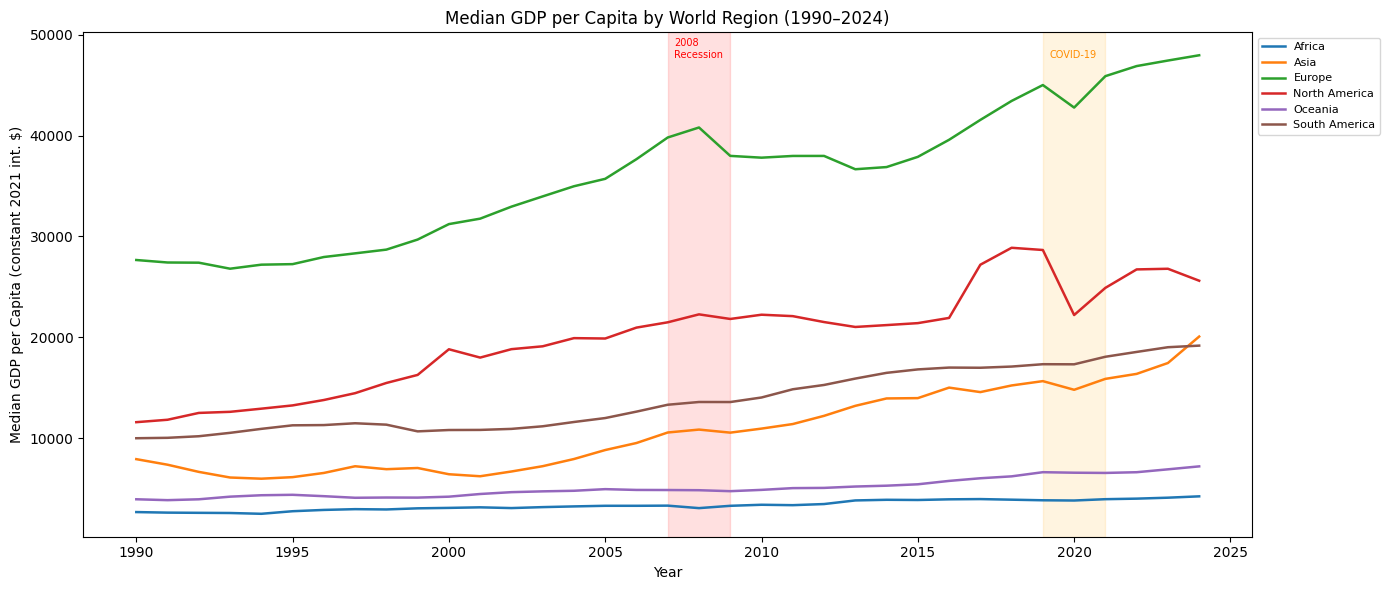

In [10]:
# Median GDP per capita by region and year
region_gdp = df_reg.dropna(subset=['region']).groupby(['region', 'year'])['gdp_per_capita'].median().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
regions = region_gdp['region'].unique()
palette = sns.color_palette('tab10', len(regions))

for i, region in enumerate(regions):
    rdata = region_gdp[region_gdp['region'] == region]
    ax.plot(rdata['year'], rdata['gdp_per_capita'], label=region, color=palette[i], linewidth=1.8)

ax.axvspan(2007, 2009, alpha=0.12, color='red')
ax.axvspan(2019, 2021, alpha=0.12, color='orange')
ax.text(2007.2, ax.get_ylim()[1]*0.95, '2008\nRecession', fontsize=7, color='red')
ax.text(2019.2, ax.get_ylim()[1]*0.95, 'COVID-19', fontsize=7, color='darkorange')

ax.set_title('Median GDP per Capita by World Region (1990–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Median GDP per Capita (constant 2021 int. $)')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(r'..\output\regional_gdp_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. GDP Growth Rate During Shocks — Regional Boxplot

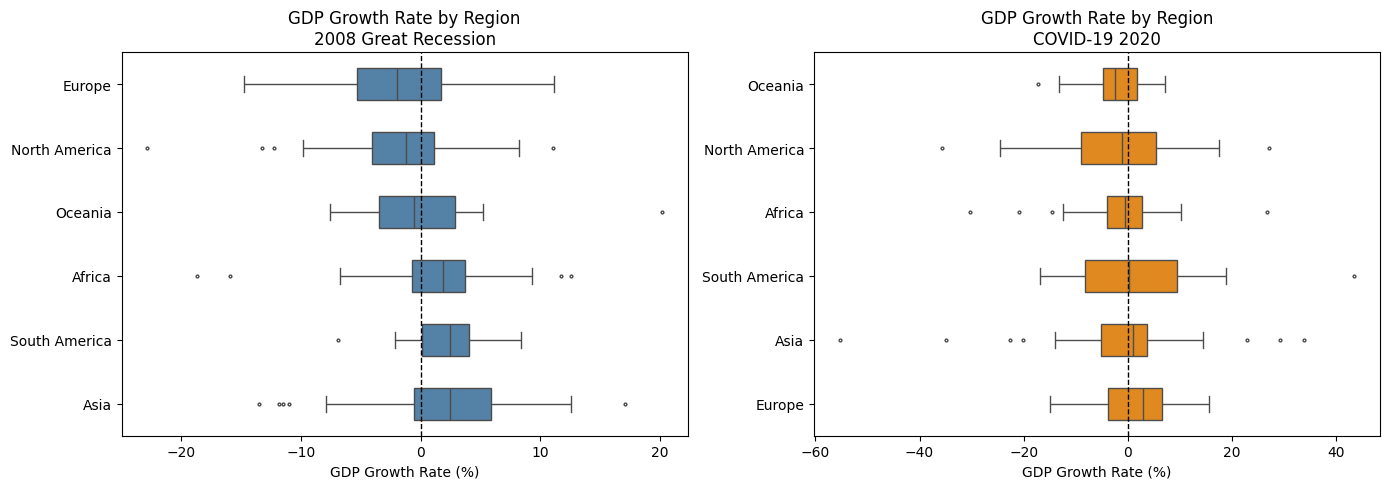

In [11]:
shock_regional = df_reg[df_reg['is_shock'] == 1].dropna(subset=['region', 'gdp_growth_rate'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (shock_lbl, shock_years, color) in zip(axes, [
    ('2008 Great Recession', [2008, 2009], 'steelblue'),
    ('COVID-19 2020',        [2020, 2021], 'darkorange'),
]):
    data = df_reg[df_reg['year'].isin(shock_years)].dropna(subset=['region', 'gdp_growth_rate'])
    order = data.groupby('region')['gdp_growth_rate'].median().sort_values().index
    sns.boxplot(data=data, x='gdp_growth_rate', y='region', order=order,
                color=color, ax=ax, width=0.5, fliersize=2)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'GDP Growth Rate by Region\n{shock_lbl}')
    ax.set_xlabel('GDP Growth Rate (%)')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(r'..\output\regional_shock_growth_boxplot.png', dpi=150)
plt.show()

## 7. Correlation Analysis — Economic & Demographic Indicators

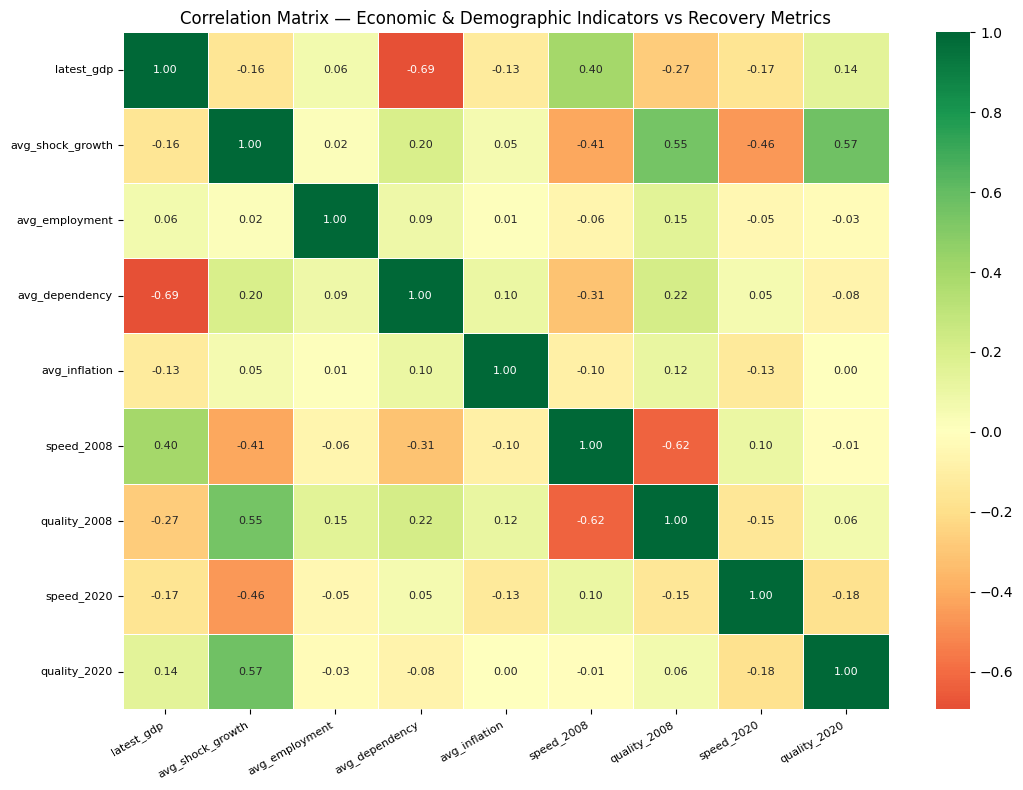

In [12]:
# Correlate indicators with recovery speed and quality
corr_cols = [
    'latest_gdp', 'avg_shock_growth',
    'avg_employment', 'avg_dependency', 'avg_inflation',
    'speed_2008', 'quality_2008',
    'speed_2020', 'quality_2020',
]
corr_cols = [c for c in corr_cols if c in country_summary.columns]

corr_matrix = country_summary[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax, annot_kws={'size': 8},
    xticklabels=corr_cols, yticklabels=corr_cols
)
ax.set_title('Correlation Matrix — Economic & Demographic Indicators vs Recovery Metrics')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(r'..\output\spatial_correlation_heatmap.png', dpi=150)
plt.show()

## 8. Top and Bottom Recovery Performers

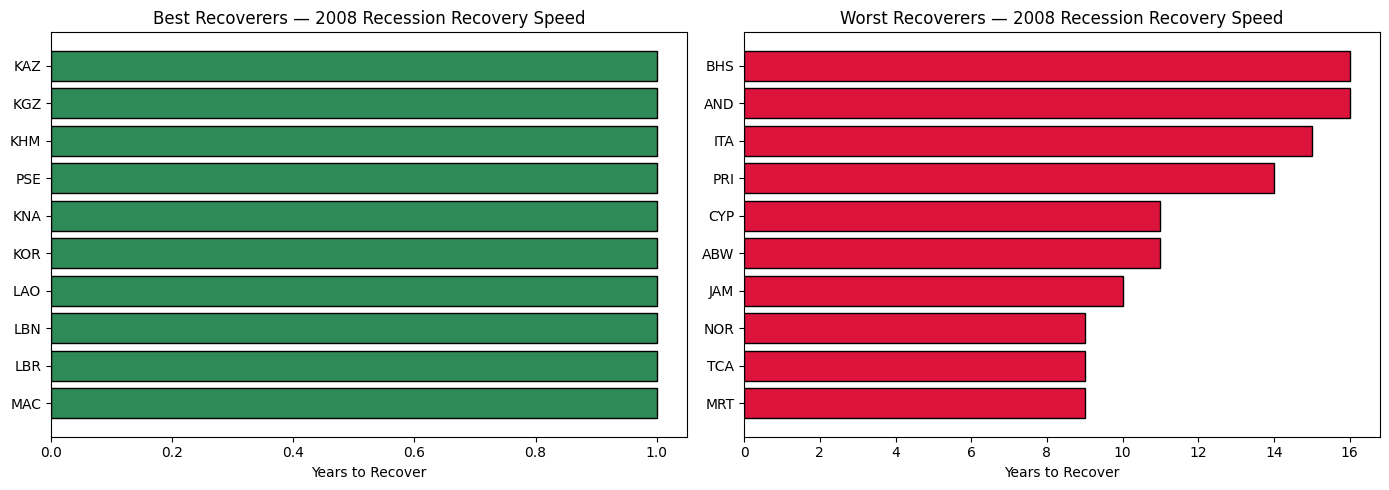

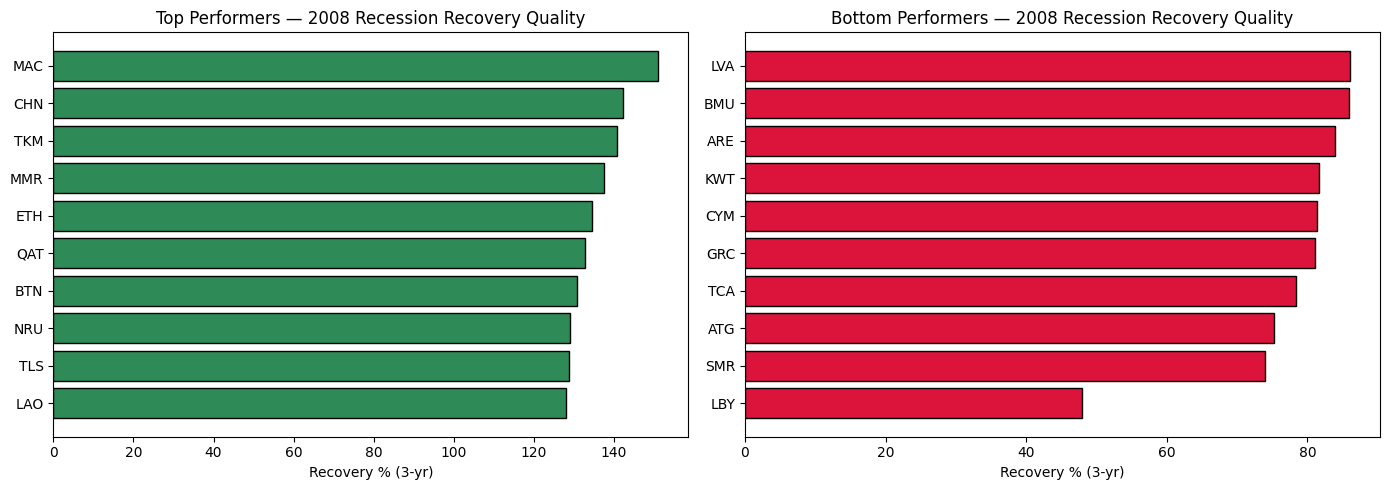

In [13]:
def plot_top_bottom(column, title, xlabel, n=10, lower_is_better=False):
    data = country_summary[['country_code', column]].dropna().sort_values(column)
    if lower_is_better:
        top    = data.head(n)     # lowest = best
        bottom = data.tail(n)     # highest = worst
        top_label, bottom_label = 'Best Recoverers', 'Worst Recoverers'
    else:
        top    = data.tail(n)     # highest = best
        bottom = data.head(n)     # lowest = worst
        top_label, bottom_label = 'Top Performers', 'Bottom Performers'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(top['country_code'],    top[column],    color='seagreen', edgecolor='black')
    axes[0].set_title(f'{top_label} — {title}')
    axes[0].set_xlabel(xlabel)
    axes[1].barh(bottom['country_code'], bottom[column], color='crimson',  edgecolor='black')
    axes[1].set_title(f'{bottom_label} — {title}')
    axes[1].set_xlabel(xlabel)
    plt.tight_layout()
    return fig

# 2008 Recovery Speed (lower = faster = better)
fig = plot_top_bottom('speed_2008', '2008 Recession Recovery Speed', 'Years to Recover', lower_is_better=True)
plt.savefig(r'..\output\top_bottom_speed_2008.png', dpi=150)
plt.show()

# 2008 Recovery Quality (higher = better)
fig = plot_top_bottom('quality_2008', '2008 Recession Recovery Quality', 'Recovery % (3-yr)', lower_is_better=False)
plt.savefig(r'..\output\top_bottom_quality_2008.png', dpi=150)
plt.show()

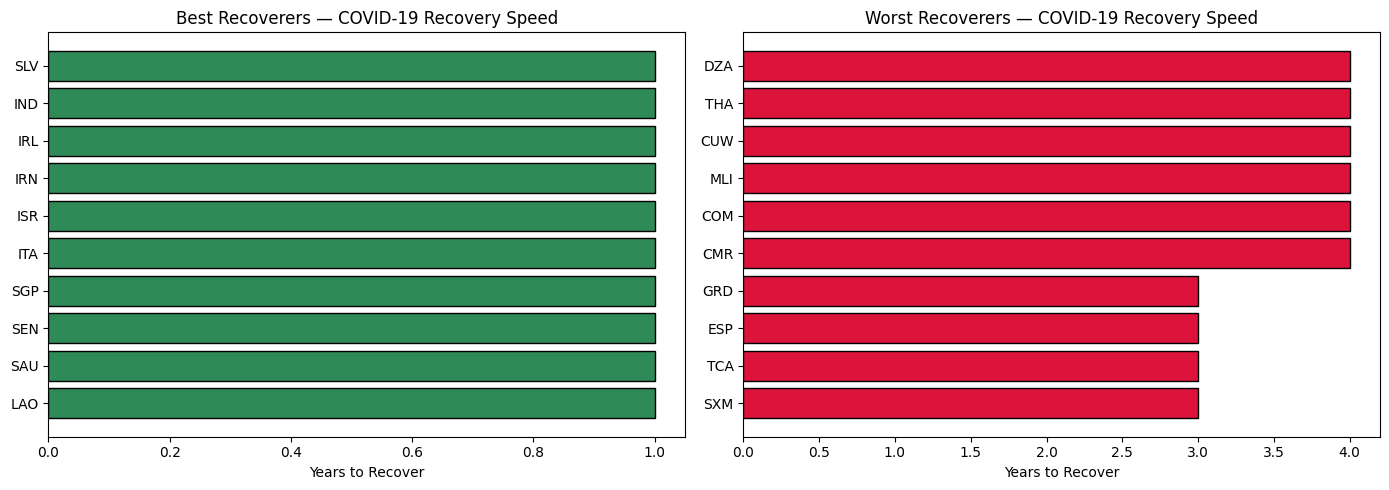

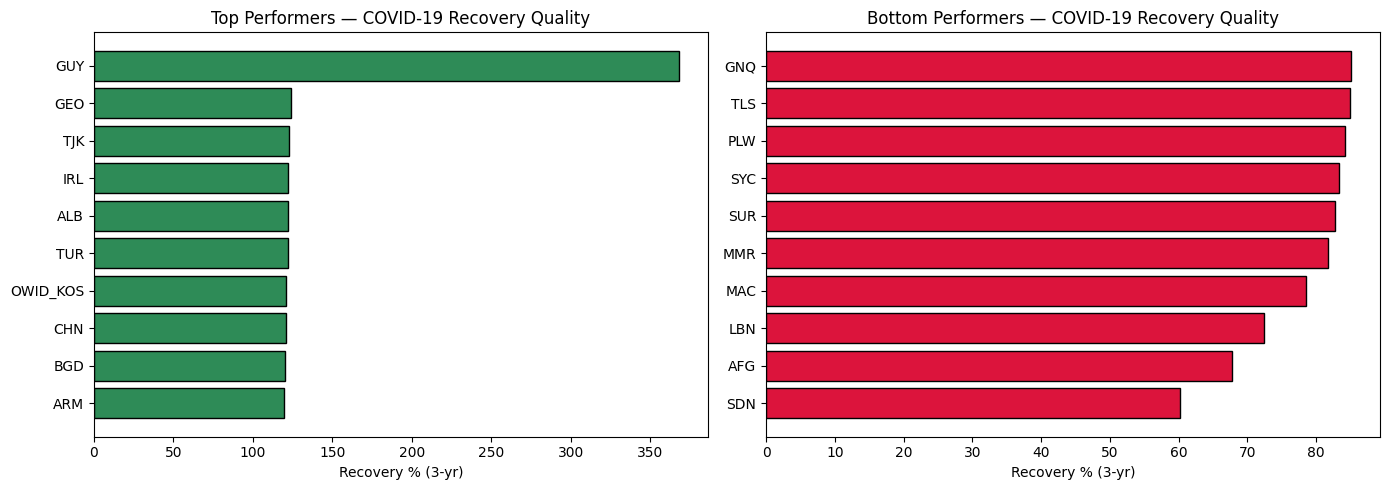

In [14]:
# COVID-19 Recovery
fig = plot_top_bottom('speed_2020', 'COVID-19 Recovery Speed', 'Years to Recover', lower_is_better=True)
plt.savefig(r'..\output\top_bottom_speed_2020.png', dpi=150)
plt.show()

fig = plot_top_bottom('quality_2020', 'COVID-19 Recovery Quality', 'Recovery % (3-yr)', lower_is_better=False)
plt.savefig(r'..\output\top_bottom_quality_2020.png', dpi=150)
plt.show()

## 9. Country Clustering by Recovery Profile

K-Means clustering groups countries by similar recovery behaviour across both shocks.

Countries available for clustering: 145


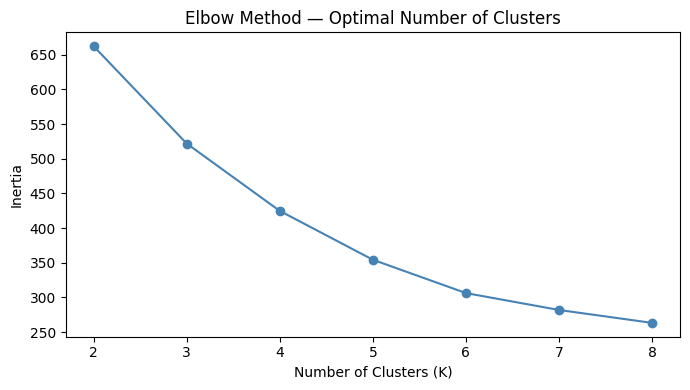

In [15]:
cluster_cols = ['speed_2008', 'quality_2008', 'speed_2020', 'quality_2020', 'latest_gdp', 'avg_employment']
cluster_df = country_summary[['country_code'] + cluster_cols].dropna()
print('Countries available for clustering:', len(cluster_df))

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_cols])

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig(r'..\output\cluster_elbow.png', dpi=150)
plt.show()

In [16]:
# Apply K-Means with K=4 (adjust based on elbow)
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km.fit_predict(X_scaled)

# Add descriptive cluster names
cluster_names = {
    0: "Resilient Emerging",
    1: "Outlier",
    2: "Struggling Developed",
    3: "Resilient Low-Income"
}
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)

print('Cluster sizes:')
print(cluster_df['cluster'].value_counts().sort_index())

print('\nCluster profiles:')
for cluster_id in range(K):
    mask = cluster_df['cluster'] == cluster_id
    print(f"{cluster_names[cluster_id]} ({mask.sum()} countries):")
    print(cluster_df[mask][cluster_cols].mean())
    print()


Cluster sizes:
cluster
0    85
1     1
2    38
3    21
Name: count, dtype: int64

Cluster profiles:
Resilient Emerging (85 countries):
speed_2008           1.31
quality_2008       113.30
speed_2020           1.25
quality_2020       108.50
latest_gdp       20120.68
avg_employment      58.53
dtype: float64

Outlier (1 countries):
speed_2008           1.00
quality_2008       117.16
speed_2020           1.00
quality_2020       367.94
latest_gdp       70516.72
avg_employment      49.63
dtype: float64

Struggling Developed (38 countries):
speed_2008           6.50
quality_2008        97.20
speed_2020           1.42
quality_2020       104.98
latest_gdp       56395.26
avg_employment      56.58
dtype: float64

Resilient Low-Income (21 countries):
speed_2008           2.00
quality_2008       108.79
speed_2020           3.10
quality_2020       101.89
latest_gdp       12904.08
avg_employment      50.56
dtype: float64



PCA explained variance: 55.3%


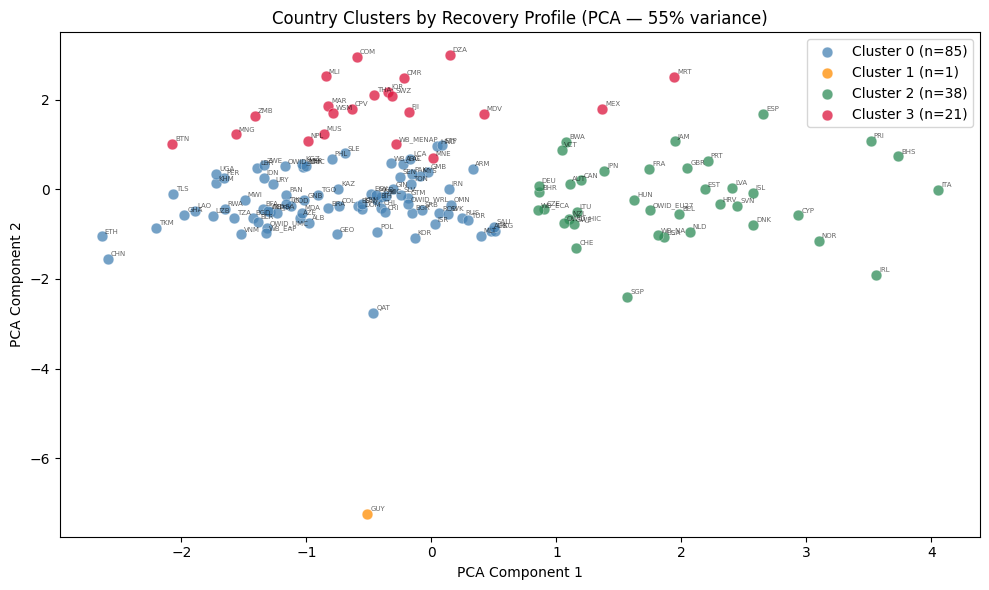

In [17]:
# PCA 2D scatter plot of clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cluster_df['pca1'] = X_pca[:, 0]
cluster_df['pca2'] = X_pca[:, 1]

print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']
for cluster_id in sorted(cluster_df['cluster'].unique()):
    cdata = cluster_df[cluster_df['cluster'] == cluster_id]
    ax.scatter(cdata['pca1'], cdata['pca2'], c=colors[cluster_id],
               label=f'Cluster {cluster_id} (n={len(cdata)})', s=60, alpha=0.75, edgecolors='white', linewidth=0.3)
    for _, row in cdata.iterrows():
        ax.annotate(row['country_code'], (row['pca1'], row['pca2']),
                    fontsize=5, alpha=0.6, textcoords='offset points', xytext=(2, 2))

ax.set_title(f'Country Clusters by Recovery Profile (PCA — {pca.explained_variance_ratio_.sum()*100:.0f}% variance)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend()
plt.tight_layout()
plt.savefig(r'..\output\country_clusters_pca.png', dpi=150)
plt.show()

In [18]:
# Choropleth map of clusters
fig = px.choropleth(
    cluster_df,
    locations='country_code',
    color='cluster_name',
    color_discrete_map={
        'Resilient Emerging': '#1f77b4',
        'Struggling Developed': '#ff7f0e',
        'Resilient Low-Income': '#2ca02c',
        'Outlier': '#d62728'
    },
    title='Country Clusters by Recovery Profile',
    labels={'cluster_name': 'Cluster Profile'},
    projection='natural earth',
)
fig.update_layout(
    geo=dict(projection_type='natural earth'),
    title_font_size=14,
)
fig.show()
print('Saved: output/phase3_cluster_map.png')


Saved: output/phase3_cluster_map.png


## 10. Demographic Indicators vs Recovery Quality — Scatter Plots

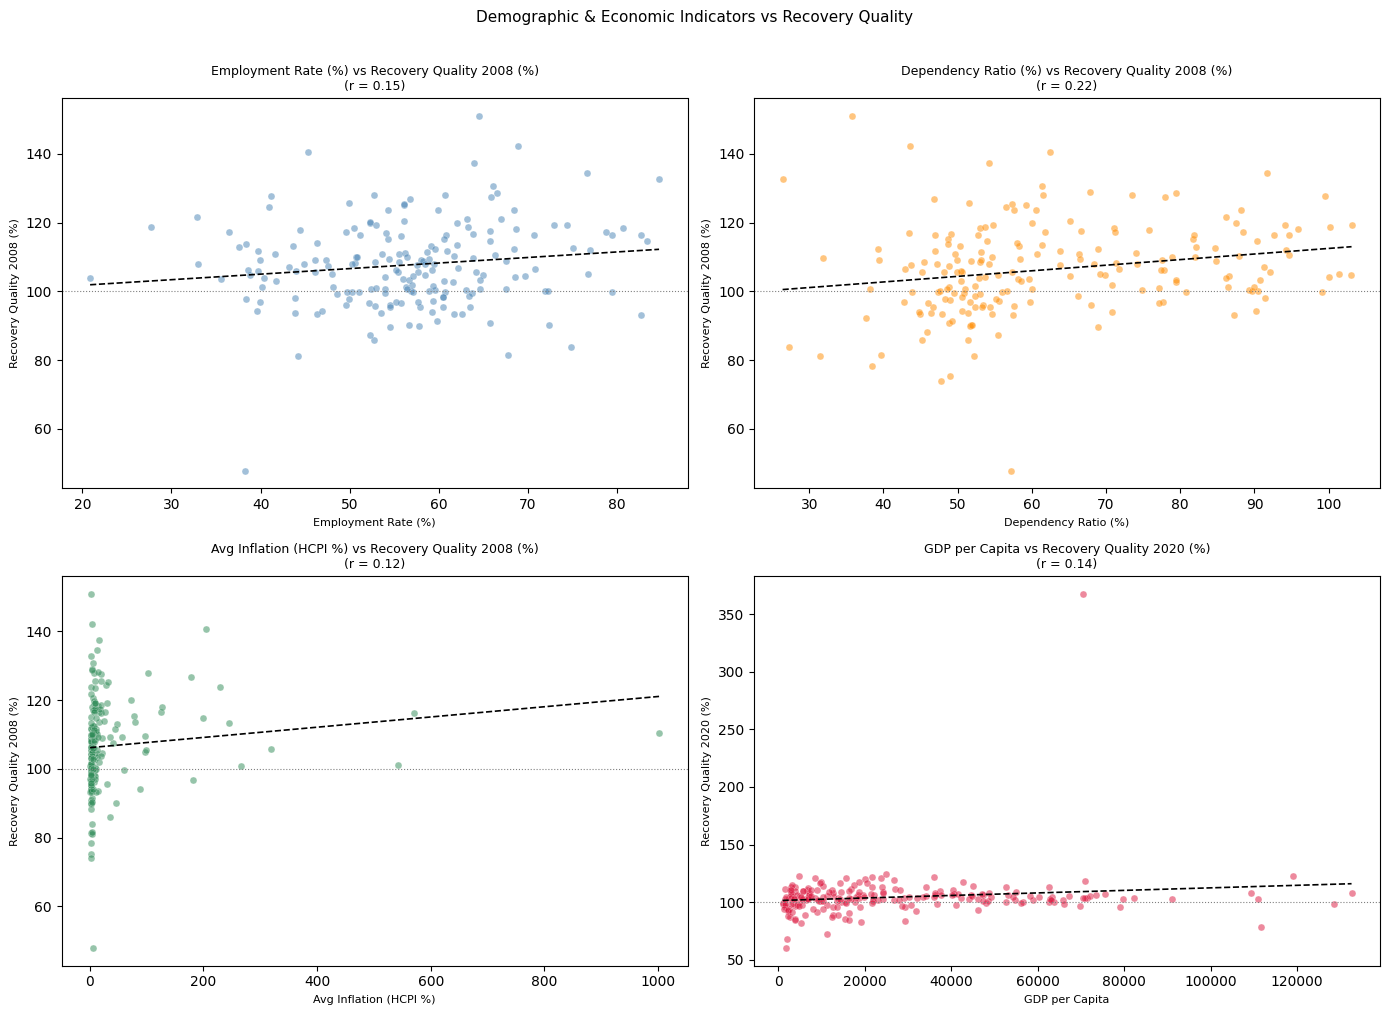

In [19]:
scatter_pairs = [
    ('avg_employment',  'quality_2008', 'Employment Rate (%)', 'Recovery Quality 2008 (%)', 'steelblue'),
    ('avg_dependency',  'quality_2008', 'Dependency Ratio (%)', 'Recovery Quality 2008 (%)', 'darkorange'),
    ('avg_inflation',   'quality_2008', 'Avg Inflation (HCPI %)', 'Recovery Quality 2008 (%)', 'seagreen'),
    ('latest_gdp',      'quality_2020', 'GDP per Capita', 'Recovery Quality 2020 (%)', 'crimson'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (xcol, ycol, xlabel, ylabel, color) in zip(axes, scatter_pairs):
    data = country_summary[[xcol, ycol]].dropna()
    ax.scatter(data[xcol], data[ycol], alpha=0.5, color=color, s=25, edgecolors='white', linewidth=0.3)
    # Trend line
    m, b = np.polyfit(data[xcol], data[ycol], 1)
    x_line = np.linspace(data[xcol].min(), data[xcol].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.2, linestyle='--')
    ax.axhline(100, color='grey', linestyle=':', linewidth=0.8)
    corr = data[xcol].corr(data[ycol])
    ax.set_title(f'{xlabel} vs {ylabel}\n(r = {corr:.2f})', fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)

plt.suptitle('Demographic & Economic Indicators vs Recovery Quality', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(r'..\output\demographic_vs_recovery_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Country Summary

In [20]:
# ── Save country summary with cluster labels ─────────────────────────────
country_summary = country_summary.merge(
    cluster_df[['country_code', 'cluster', 'cluster_name']], on='country_code', how='left'
)
country_summary.to_csv(r'..\output\country_summary.csv', index=False)
print('Country summary saved with cluster labels')


Country summary saved with cluster labels


---
## Phase 3 Complete

| Analysis | Output File |
|---|---|
| GDP per capita map | `map_gdp_latest.html` |
| Shock impact map | `map_shock_impact.html` |
| Recovery speed maps (2008, 2020) | `map_recovery_speed_2008/2020.html` |
| Recovery quality map (2008) | `map_recovery_quality_2008.html` |
| Regional GDP trends | `regional_gdp_trends.png` |
| Regional shock boxplots | `regional_shock_growth_boxplot.png` |
| Correlation heatmap | `spatial_correlation_heatmap.png` |
| Top/bottom performers | `top_bottom_speed/quality_2008/2020.png` |
| Country clusters (PCA + map) | `country_clusters_pca.png`, `map_country_clusters.html` |
| Demographic scatter plots | `demographic_vs_recovery_scatter.png` |
| Country summary CSV | `country_summary.csv` |

**Next → Phase 4:** Time Series Analysis — XGBoost Model